In [45]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# yf can be noisy about progress bars - keeps output clean

import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)


In [46]:
# first step - choose pair and pick a date range

TICKER_A = "SHEL"
TICKER_B = "BP"

START_DATE = "2022-01-01"
END_DATE = "2025-01-01"

# yf dataframe downloads table of open, high, low, close, volume and adjusted close prices for the ticker

data = yf.download([TICKER_A, TICKER_B], start=START_DATE, end=END_DATE, auto_adjust=True)["Close"]

data = data.dropna()  # drop any rows with missing values
data.head()  # show the first few rows of the dataframe



[*********************100%***********************]  2 of 2 completed


Ticker,BP,SHEL
Date,,
2022-01-03,21.583637,37.489555
2022-01-04,22.514172,38.606529
2022-01-05,22.372225,38.623325
2022-01-06,22.719206,39.253189
2022-01-07,23.397385,39.698292


<Axes: title={'center': 'Naive spread (SHEL/BP)'}, xlabel='Date'>

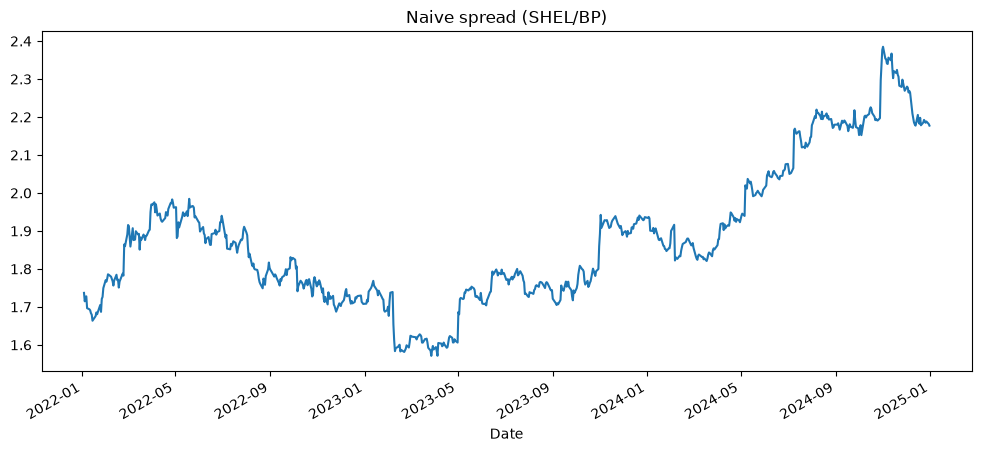

In [47]:
# construct naive spread
# since they trade at quite different price levels, use price ratio instead of price difference

def compute_spread(data, TICKER_A, TICKER_B):
    return data[TICKER_A] / data[TICKER_B]

spread = compute_spread(data, TICKER_A, TICKER_B)

spread.plot(title=f"Naive spread ({TICKER_A}/{TICKER_B})")



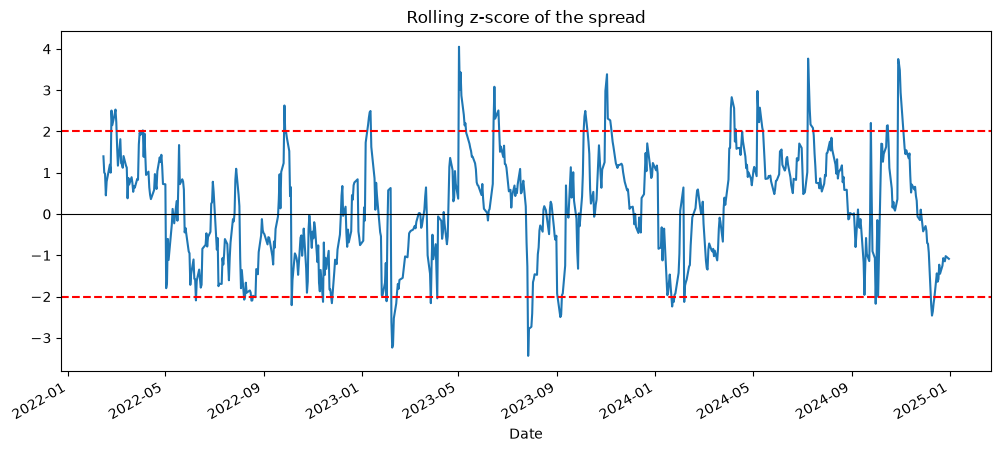

In [48]:
# rolling z score of the spread

def compute_zscore(spread: pd.Series, window: int = 30) -> pd.Series:
    mean = spread.rolling(window=window).mean()
    std = spread.rolling(window=window).std()
    return (spread - mean) / std

zscore = compute_zscore(spread, window=30)
zscore.plot(title=f"Rolling z-score of the spread")
plt.axhline(2, color="red", linestyle="--")
plt.axhline(-2, color="red", linestyle="--")
plt.axhline(0, color="black", linewidth=0.8)


<Axes: title={'center': 'Position over time (+1 long spread / -1 short spread / 0 flat)'}, xlabel='Date'>

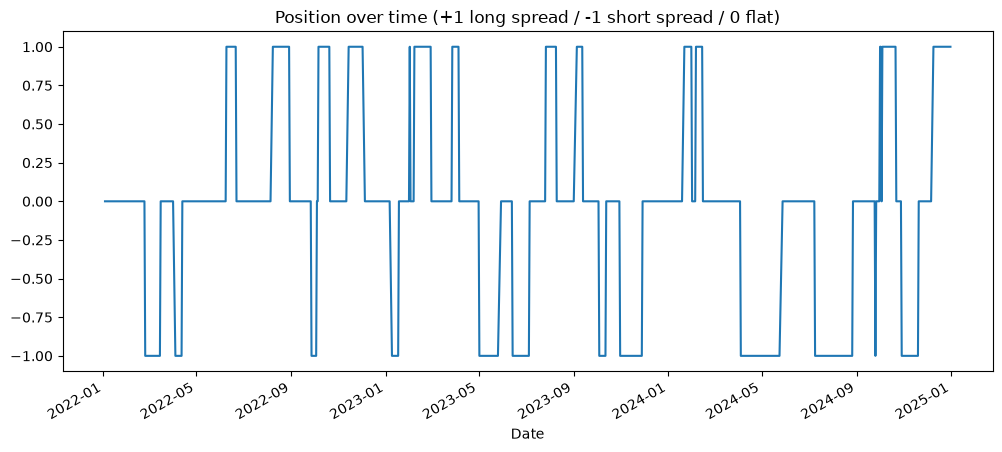

In [49]:
# generate trading signals based on z-score thresholds
# if z-score > entry threshold, spread is wider than expected, so short the spread expecting it to fall back to mean. short A long B
# if z-score < -entry threshold, spread is narrower than expected, so long the spread expecting it to rise back to mean. long A short B
# if in a position, and z-score crosses exit threshold, close the position

def generate_signals(zscore: pd.Series, entry_threshold: float = 2.0, exit_threshold: float = 0.5) -> pd.Series:
    position = [] # starting position flat = 0, long = 1, short = -1
    current_position = 0  # Initialize current position
    for i in range(0, len(zscore)):
        if current_position == 0: # no position
            if zscore.iloc[i] > entry_threshold:
                current_position = -1  # short the spread

            elif zscore.iloc[i] < -entry_threshold:
                current_position = 1  # long the spread

            else:
                current_position = 0  # maintain no position

        elif current_position == 1: # currently long
            if abs(zscore.iloc[i]) < exit_threshold:
                current_position = 0  # close the position

            else:
                current_position = 1  # maintain the long position

        elif current_position == -1: # currently short
            if abs(zscore.iloc[i]) < exit_threshold:
                current_position = 0  # close the position

            else:
                current_position = -1  # maintain the short position

        position.append(current_position)  # record the current position
    return pd.Series(position, index=zscore.index)

positions = generate_signals(zscore, entry_threshold=2.0, exit_threshold=0.5)
positions.plot(title="Position over time (+1 long spread / -1 short spread / 0 flat)")
    


<Axes: title={'center': 'Cumulative P&L (naive baseline)'}, xlabel='Date'>

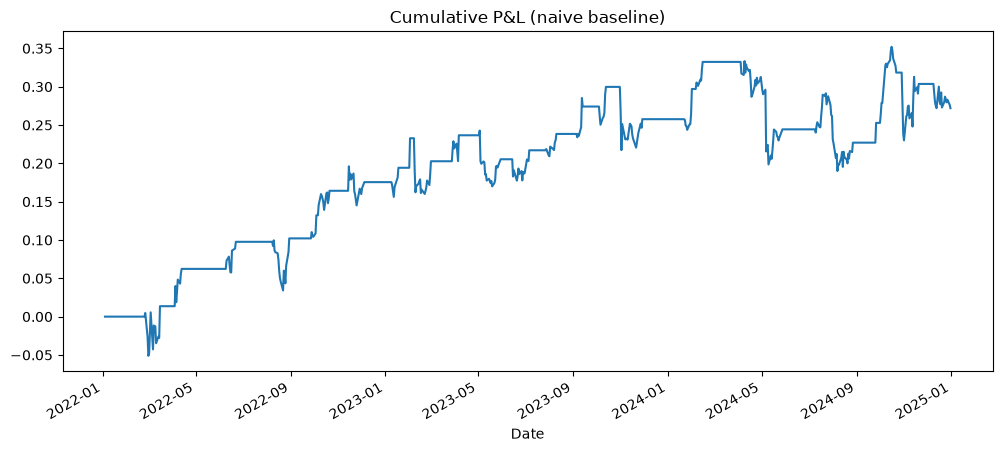

In [50]:
# backtest, turn positions into p&l
# standard approach, p&l = yesterday's position * today's spread change
# use positions.shift(1) to get yesterday's position, and spread.diff() to get today's spread change

def backtest(positions: pd.Series, spread: pd.Series) -> pd.Series:
    return positions.shift(1) * spread.diff()

daily_pnl = backtest(positions, spread)
cumulative_pnl = daily_pnl.cumsum()
cumulative_pnl.plot(title="Cumulative P&L (naive baseline)")


  

In [51]:
# performance metrics

def sharpe_ratio(daily_pnl: pd.Series, periods_per_year: int = 252) -> float:
    # assuming risk free rate - annualized Sharpe ratio = (mean daily return / std daily return) * sqrt(periods per year)
    mean_daily_return = daily_pnl.mean()
    std_daily_return = daily_pnl.std()
    return (mean_daily_return / std_daily_return) * np.sqrt(periods_per_year)

sr = sharpe_ratio(daily_pnl.dropna())
print(f"Naive baseline Sharpe ({TICKER_A}/{TICKER_B}): {sr:.2f}")
print(f"Total P&L (spread units): {cumulative_pnl.iloc[-1]:.2f}")
print(f"Number of trades: {(positions.diff() != 0).sum()}")

Naive baseline Sharpe (SHEL/BP): 0.59
Total P&L (spread units): 0.27
Number of trades: 52
